In [57]:
import numpy as np
from scipy.stats import multivariate_normal
import nbimporter

In [58]:
class Algoritmer: 
    """
    Algoritmer lavet til SLML
    """

# Gaussian_mixture
$$p(x) = \sum_{k=1}^K{\pi_k \mathscr{N}(x\lvert \mu_k, \Sigma_k)}$$

In [59]:
def gaussian_mixture(x, means, covariances, pis):
        # x in R^1xD 
        # u in R^KxD
        # ∑ in R^KxDxD
        # pi in R^K
        
        px = np.sum([
            pis[k] * multivariate_normal.pdf(x, means[k], covariances[k])    for k in range(means.shape[0])
            ])
        return px
Algoritmer.gaussian_mixture = gaussian_mixture

# Expectation Maximation 
Evaluering: 
$$ \gamma(z_{nk}) = \frac{
    \pi_k \mathscr{N}(x_n\lvert \mu_k, \Sigma_k)
}{
    \sum_{j=1}^K{\pi_j \mathscr{N}(x_n\lvert \mu_j, \Sigma_j)}
}$$
Updatering: 

$$N_k = \sum_{n=1}^N{\gamma(z_{nk})}$$
$$\mu_k^{new} = \frac{1}{N_k}\sum_{n=1}^N {\gamma(z_{nk})x_n}$$
$$\Sigma_k^{new} = \frac{1}{N_k}\sum_{n=1}^N {\gamma(z_{nk})(x_n - \mu_k^{new})(x_n - \mu_k^{new})^T}$$
$$\pi_k^{new} = \frac{N_k}{N}$$
Evaluer log likelihood 
$$ lnp(X\lvert \mu, \Sigma, \pi) = \sum_{n=1}^N {ln{\sum_{k=1}^K{\pi_k \mathscr{N}(x_n\lvert \mu_k, \Sigma_k)} }} $$

Tjek så for konvergering af parametre eller for log likelihood. Hvis kriteriet ikke er mødt, start så forfra

In [60]:
def expectation_maximization_gaussian(mus_0, covariances_0, pis_0, data_x, on_step):
        # data_x in R^{NxD}
        # u in R^KxD
        # ∑ in R^KxDxD
        # pi in R^K
        N = data_x.shape[0]
        K, D = mus_0.shape
        
        ikkeKonvergeret = True
        threshold = 1e-6
        globalLogLikeliHood = [100]        # Bruges til at tjekke konvergens.
        
        
        while ikkeKonvergeret : 
            
            # Evaluering
            # gamma_nk in R^{N_K}
            gamma = np.array([
                [pis_0[k] * multivariate_normal.pdf(data_x[n], mus_0[k], covariances_0[k])    for k in range(K)]
                for n in range(N)
                            ])        
            # Normalisering: /= R^{N_1}
            gamma /= np.sum(gamma, axis = 1)[:, np.newaxis]
            
            
            # Opdatering
            N_k = np.sum(gamma, axis = 0) # Sum ned ad rækkerne in R^K, 
                                                                                                                                        # gamma_n in R^1xK x_n in R^1xD. gamma_n^T * x_n in R^KxD # R^1xK * sum_n(R^NxKxD) -> R^1xK * R^KxD # Hvad med en diagonal invers? # Min lineær algebra siger, at det medføre en invers af hvert element og beholder dem på diagonalen.  A = np.array([1, 2, 5, 10]); B = np.diag(A); C = np.linalg.inv(B) # print(A);print(B); print(C) # Det gør den! # R^KxK * R^KxD # at N_k = 0 for n ≠ k skulle medføre, at til kun den klasse, som inversen tilhøre, skulle den blive normaliseret.
            mu_new = (1/N_k)[:, np.newaxis] * (gamma.T @ data_x) # R^Kx1 * R^{KxN . NxD} = R^Kx1 * R^KxD -> R^KxD
            # kovariancen skulle vidst ikke være hurtigere på vektor form
            Sigma_new = np.zeros((K, D, D))
            for k in range(K): 
                diff = data_x - mu_new[k]                   # R^NxD - R^1xD -> R^NxD
                weight = gamma[:, k][:, np.newaxis] * diff  # R^Nx1 * R^NxD -> R^NxD                 <- Elementwise operator på hver række. 
                Sigma_new[k] = 1/N_k[k] * (weight.T @ diff) # R^1x1 . R^DxN . R^NxD -> R^DxD
                
            pik_new = N_k/N 
            
            
            # Ny evaluering
            loglikelihood = np.sum(
                np.log([Algoritmer.gaussian_mixture(x, mu_new, Sigma_new, pik_new) for x in data_x])
            )
            # Predictions? 
            # gamma fortæller om sandsynligheden for et datapunkt x i hvilken som helst klasse, normaliseret med sandsynligheden for at den bare er i en. 
            # Dermed så må den klasse hvis sandsynlighed er størst for datapunktet x betyde, at det er den klasse som den tilhøre. 
            # gamma in R^NxK 
            t = np.argmax(gamma, 1)
            
            
            # Feedback
            # On_step = lambda mus, covs, pis, log_likelihood, predictions: all_steps_em.append((mus, covs, pis, log_likelihood, predictions))
            on_step(mu_new, Sigma_new, pik_new, loglikelihood, t)
            
            # sum(loglikelihood_n) in [150*ln(0); 150*ln(1)] = [-∞; 0]
            dLikeliHood = np.abs(loglikelihood) - np.abs(globalLogLikeliHood[-1])
            if np.abs(dLikeliHood) < threshold: break 
            globalLogLikeliHood.append(np.abs(loglikelihood))
            
            
            # Nye værdier bliver til gamle
            mus_0 = mu_new
            covariances_0 = Sigma_new
            pis_0 = pik_new

Algoritmer.expectation_maximization_gaussian = expectation_maximization_gaussian

# PCA projection
Målet: 
$$\tilde{x}_{n}=\bar{x}+\sum_{i=1}^{M}(x_{n}^{T}{u}_{i}- \bar{x^T} u_i)u_i$$
For det så skal jeg få 
$$\bar{x} = \frac{\sum_N{x_n}}{N}$$
Og U vektoren bliver lavet ud fra M komponenter af egenvektorerne for covariance matricen S
$$ S = \frac{1}{N} \sum_{n=1}^N{(x_n -\bar{x})(x_n -\bar{x})^T} \Rightarrow U \in\R^{DxM} \le \R^{DxD} $$

In [61]:
def pca_projection(data, components):
    N, D = data.shape
    M = components
    # Steps: 
    #   1. Find x_mean 
    #   2. Lav covariance matrix 
    #   3. Find tilsvarende egenvektorer.
    #   4. Lav x pca approximation. 
    
    X = data
    # X in R^{NxD} 
    # X_mean in R^{1xD}
    X_mean = 1/N * np.sum(data, axis=0)[:, np.newaxis].T
    diff = X - X_mean           # <- Elementvis operation på rækkeren   R^{NxD} - R^{1xD} -> R^{NxD}
    
    # S = 1/N * (diff @ diff.T)             # R^{1x1} * (R^{NxD} . R^{DxN) -> R^{NxN}   <- Ugyldig
    S = 1/N * (diff.T @ diff)               # R^{1x1} * (R^{DxN} . R^{NxD) -> R^{DxD}
    eigVals, eigVecs = np.linalg.eig(S)     # R^{D, }, R^{DxD}
    
    # Egenværdierne er sorteret efter største værdi først allerede. 
    U = eigVecs[:, :M]                      # R^{DxM}                 
    
    # Jeg prøvede at udlede en repræsentation selv, men jeg fandt ikke et rigtig resultat 
    
    # Af en eller anden grund er min U flippet i forhold til Naveeds, så for at få det samme som ham så ukommenter det her. 
    U *= -1 
    # Chatten fortæller at retningen er ligegyldigt, at det bare er ud fra den måde egenværdierne er beregnet. 
    # Så hvis han ikke lige har brugt præcis np.linalg.eig kan det være at de har andre konventioner.
    
    
    xtilde = X @ U
    return xtilde

Algoritmer.pca_projection = pca_projection

# Linear klassifikation

In [62]:
class LinearKlassifikation: 
    """
    Linear klassifikation for algoritmer indenfor SLML.
    Noget som least squares og logistisk regression. 
    """
Algoritmer.LinearKlassifikation = LinearKlassifikation

## Least squares
$$ \tilde{W} = \tilde{X}^\dagger T $$
$$ \tilde{X}^\dagger = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T $$
$$ \tilde{X} \in \mathbb{R}^{NxD} $$
$$ \tilde{T} \in \mathbb{R}^{Nx1} $$
For at tage højde for bias så laves design matricen. 

$$\Phi = [1, \tilde{x}_1, \tilde{x}_2] \in \mathbb{R}^{Nx(D+1)}$$
Og bruger den i stedet for X. 
Se slide 13-15 i forelæsning 13, for mere teori. 

In [63]:
def W_least_squares(X, T):
    # X is in R^NxD     <- R^Nx2
    # T is in R^Nx1     <- R^Nx2
    N, D = X.shape
    PHI = np.hstack((np.ones((N, 1)), X))  # PHI in R^Nx(D+1)
    PHI_pseudo = np.linalg.inv(PHI.T @ PHI) @ PHI.T  # in R^(D+1)xN . R^Nx(D+1) . R^(D+1)xN = R^(D+1)xN
    W = PHI_pseudo @ T  # R^(D+1)xN . R^Nx1 -> # W in R^(D+1)x1
    return W
Algoritmer.LinearKlassifikation.W_least_squares = W_least_squares

### Predictions 

#### Binary predictions 
$$t_n = \begin{cases} C_1, & y_n > boundary \\ C_2, & ellers \end{cases}

In [64]:
def prediction_bineær(W, X, boundary):
    # X in R^{NxD}
    # W in R^{(D + 1)x1} 
    N, D = X.shape
    Phix = np.hstack((np.ones((N, 1)), X))      # PHI in R^Nx(D+1)
    y = np.zeros((N, 1))
    t = np.zeros((N, 1))
    y = Phix @ W            # R^{Nx(D+1)} . R^{(D+1)x1} -> R^{Nx1}
    t = (y >= boundary).astype(int)
    return t
Algoritmer.LinearKlassifikation.prediction_bineær = prediction_bineær

#### Multiclass predictions
$$ p(C_k \lvert x) = \frac{e^{\alpha_k}}{\sum_{j=1}^K e^{\alpha_j}} $$
Er funktionen vi kalder softmax funktionen for multiclass klassifikation. 
Men numerisk bliver det ustabilt. 
Der gælder at 
$$ p(C_k \lvert x) \approx \begin{cases} 1, & \alpha_k >> \alpha_j \quad \text{for all j} \neq k \\ 0, & ellers\end{cases} $$
Så lad mig bare bruge den viden i stedet for.
$$\alpha \in \mathbb{R}^{N\times K}$$
Så derfor må det være max indeks på kolonnerne. 

$$p(t|w) = sum(argmax(\alpha_n) == T) / N $$

In [65]:
def prediction_multiclass(W, X, T_Mult):
    # X in R^{NxD}
    # W in R^{(D + 1)xK} 
    N, D = X.shape
    _, K = W.shape
    Phix = np.hstack((np.ones((N, 1)), X))      # PHI in R^Nx(D+1)
    alpha = Phix @ W                            # R^{Nx(D+1)} . R^{(D+1)xK} -> R^{NxK}    
    
    Y = np.argmax(alpha, axis= 1)               # R^{Nx1}
    # T er en one_hot vektor, som betyder, at den kun er anderledes fra 0 i den klasse k, som punktet tilhøre.
    T = np.argmax(T_Mult, axis= 1)              # R^{Nx1}
    # Jeg ved ikke hvad jeg skulle bruge den one_hot funktion til. 
    accuracy = np.sum(Y == T) / N
    return T, accuracy
Algoritmer.LinearKlassifikation.prediction_multiclass = prediction_multiclass

#### Decision plot

In [66]:
def predictionPlot(X, T, weights, K_classes = 2, boundary = 0.5):
    """
    Funktion som validere ens prediction når de er fundet ved at plotte data med den decision boundary ens vægte giver. 
    
    Shapes 
    ------- 
    X : (N, D)
        Data 
    T : (N, K)
        Targets, bineær eller multiklasse. Er en one_hot matrice, [[0, 0, 1], [1, 0, 0]]. Det er hvad teorien siger, så måske giver det mening senere. 
    K_classes : Skalar
        Farvekodning af antal klasser. 
    Boundary : Skalar 
        Grænseværdi som adskiller klasserne ud fra den lineære diskrimant funktion. 
    
    Fremtidig arbejde 
    -------
    Fjerne K_classes. Det er bare fordi bineær regression tager 2 værdier, {0, 1}, mens multiclass tager 2 værdier på 3 indeks. {0, 1} in [0, 1, 0]   
    """
    
    # Handy plotting functions
    x_min, x_max = -40, 40
    y_min, y_max = -40, 40
    import matplotlib.pyplot as plt 

    def plot_scatter(X, T, K_classes):     
        plt.scatter(X[:, 0], X[:, 1], c=T, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', K_classes))
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.colorbar();
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)

    def plot_decision_boundary(weights):
        x1 = np.linspace(-40, 40, 64)
        boundary = 0.5 
        x2 = -(weights[0] + weights[1]*x1 - boundary) / weights[2]    
        plt.plot(x1, x2, 'r-', label='Decision boundary')
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
        plt.xlim(x_min, x_max)
        plt.ylim(y_min, y_max)
        plt.legend()
    
    plot_scatter(X, T, K_classes)
    plot_decision_boundary(weights) 

Algoritmer.LinearKlassifikation.predictionPlot = predictionPlot

## Logistic regression
$$\phi_n \in \mathbb{R}^{1\times(D + 1)}$$
$$y - t \in \mathbb{R}^{N\times 1}$$
$$\Phi \in \mathbb{R}^{N\times (D+1)}$$
$$(y - t)^T . \Phi \in \mathbb{R}^{1\times N} . \mathbb{R}^{N\times (D+1)} \rightarrow \mathbb{R}^{1\times (D+1)}$$
Så det skulle give mig min gradient descend
$$\nabla E(w^{(\tau)}) = (y - t)^T . \Phi$$

Hvad med y? y er lavet af den logistiske sigmoid function 
$$y = \sigma(\alpha_n)$$
Hvor 
$$\alpha_n = w^T\phi(x_n)$$
så 
$$y = \sigma(w^T\phi(x_n))$$

Lad mig få dimensionerne til at gå op. 
$$w^T\phi(x_n) \in \mathbb{R}^{1\times(D + 1)}.\mathbb{R}^{(D + 1)\times 1}$$
Må det være. Det passer med mit setup af w. 
Hvad med for alle n'er. Design matricen er sat op på en anden måde. 
$$\Phi \in \mathbb{R}^{N\times D}$$
Så jeg må lave
$$\Phi . w \in \mathbb{R}^{N\times(D+1)} . \mathbb{R}^{(D+1)\times 1} \rightarrow \mathbb{R}^{N\times 1}$$
Så kan jeg mappe den logistiske funktion på alle af dens n'er. 

For mine beregninger så sker der overflow. Jeg har konkluderet, at det ikke betyder noget, for når alpha << 0 y ≈ 0 og når alpha >> 0 så er y ≈ 1.


In [67]:
def W_logistic(X, T, W, learning_rate=0.1, n_iterations=100) -> r"$W in R^{(D + 1)\times 1$":
    """
    Lavet til at passe til både bineær og multiklasse klassifikation.
     
    Shapes
    ------
    X : (N, D)
        Inputs
    T : (N, K)
        Targets
    W : (D+1, K)
        Weights
    
    Fremtidig arbejde
    ------
    Indføre mulighed for at bruge Hessian matricen.
    """
    sigmoid = lambda alpha : 1/(1 + np.exp(-alpha))
    def softmax(Z):
        Z = Z - np.max(Z, axis=1, keepdims=True)  # numerical stability
        expZ = np.exp(Z)
        return expZ / np.sum(expZ, axis=1, keepdims=True)
    
    N, D = X.shape
    _, K = T.shape
    Phi = np.hstack((np.ones((N, 1)), X))   # PHI in R^Nx(D+1)
    
    for _ in range(n_iterations):
        alpha = Phi @ W                                 # R^{Nx(D+1)} . R^{(D+1)xK} -> R^{NxK}
        Y = softmax(alpha) if K != 1 else sigmoid(alpha)# R^{NxK}                                          np.array([alpha_n for alpha_n in alpha.T])  # sigmoid(R^)                   # sigmoid(alpha)                          # R^{Nx(D+1)} . R^{(D+1)x1} -> R^{Nx1}
        gradient = (Y - T).T @ Phi                      # R^{KxN} . R^{Nx(D+1)}     -> R^{Kx(D+1)}
        W -= learning_rate * gradient.T                 # R^{(D+1)xK} 
    return W
Algoritmer.LinearKlassifikation.W_logistic = W_logistic

# Forsøg på at gengive øvelse 7

## Data jeg har brug for

In [68]:
# Dependencies
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set() # this import just makes the plots prettier
import numpy as np

# We're using a subset of two classes for now
digits = load_digits(n_class=2)

# The dataset contains 2D data in the form of the `images` attribute, 
# as well as a 1D-version called `data`, where the images have been flattened. 
np.array_equal(digits.images[0].flatten(), digits.data[0])

# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with

# Out targets are in the set {0,1}
t_01 = digits.target

## Least squares, vægte, validering og plot. 

True


/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_61466/2551447137.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=T, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', K_classes))


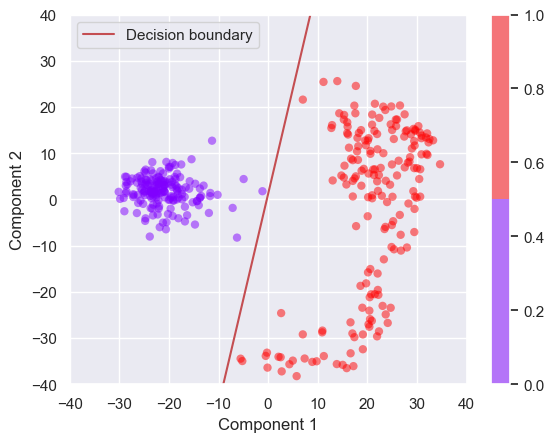

In [69]:
W_LS = Algoritmer.LinearKlassifikation.W_least_squares(X, t_01)
t_pred = Algoritmer.LinearKlassifikation.prediction_bineær(W_LS, X, 0.5 )
Algoritmer.LinearKlassifikation.predictionPlot(X, t_01, W_LS, K_classes = 2, boundary = 0.5)
print(np.allclose(t_01, t_pred))

## Logistic Regression, vægte, validering og plot

### Ekstra data jeg har brug for 

In [70]:
# initialise W_0 randomly
np.random.seed(42)
M = 3 
K = 2 
W_0 = 2 * np.random.random((M, 1)) -1 # random values in the range [-1,1]

True


/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_61466/370114573.py:18: RuntimeWarning: overflow encountered in exp
  sigmoid = lambda alpha : 1/(1 + np.exp(-alpha))
/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_61466/2551447137.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=T, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', K_classes))


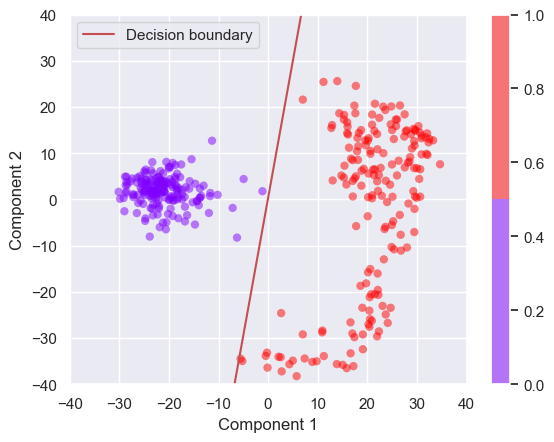

In [71]:
T = t_01[:, np.newaxis] # Har det hele vektoriseret i funktionen.
W_LR = Algoritmer.LinearKlassifikation.W_logistic(X, T, W_0)
t_pred = Algoritmer.LinearKlassifikation.prediction_bineær(W_LR, X, 0.5)
print(np.allclose(t_pred, T)) # True
Algoritmer.LinearKlassifikation.predictionPlot(X, T, W_LR, K, 0.5)

## Multiclass Logistic Regression, vægte, validering og plot


### Ekstra data jeg har brug for

In [72]:
# Data
K = 3
digits = load_digits(n_class=K)
pca = PCA(n_components=2)
X_mult = pca.fit_transform(digits.data)
learning_rate = 0.1

# initialise W_0 randomly
np.random.seed(42)
W_0 = 2 * np.random.random((M, K)) -1 # random values in the range [-1,1]

# We need to do a one_hot encoding of our data:
# I.e. 0 -> [1,0,0], 1 -> [0,1,0], 2 -> [0,0,1]
def one_hot(targets, K=K):
    res = np.eye(K)[np.array(targets).reshape(-1)]
    return res.reshape(list(targets.shape)+[K])

t_oh = one_hot(digits.target, K)

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_61466/2551447137.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(X[:, 0], X[:, 1], c=T, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', K_classes))
/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_61466/2551447137.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], c=T, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', K_classes))


0.9385474860335196


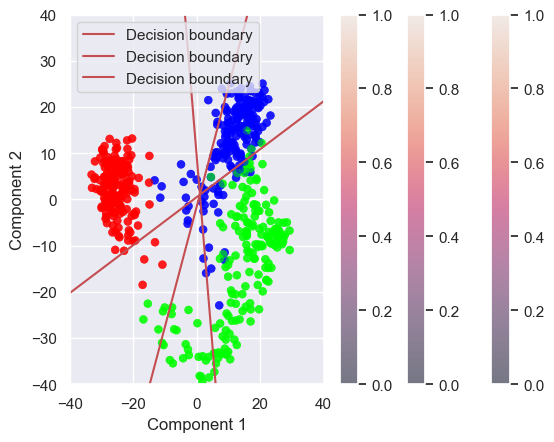

In [73]:
W_LR = Algoritmer.LinearKlassifikation.W_logistic(X_mult, t_oh, W_0)
t_pred, acc = Algoritmer.LinearKlassifikation.prediction_multiclass(W_LR, X_mult, t_oh)
print(acc) # 94% sikker
for w_k in W_LR: 
    Algoritmer.LinearKlassifikation.predictionPlot(X_mult, t_oh, w_k, K, 0.5) # <- Virker ikke rigtig på multiclass. 